         var  n_early  n_nonearly  early_yes early_%  nonearly_yes nonearly_%   OR         CI  p_fisher
   corticoid       22         136         16    72.7            45       33.1 5.39 1.98–14.72 0.0006755
      opioid       22         136         13    59.1            36       26.5 4.01 1.58–10.18  0.004967
beta_blocker       22         136          3    13.6            17       12.5 1.11  0.30–4.14         1
symptom_meds       26         152         19    73.1            62       40.8 3.94  1.56–9.94  0.002709
     any_med       26         152         19    73.1            67       44.1 3.44  1.37–8.67  0.009818


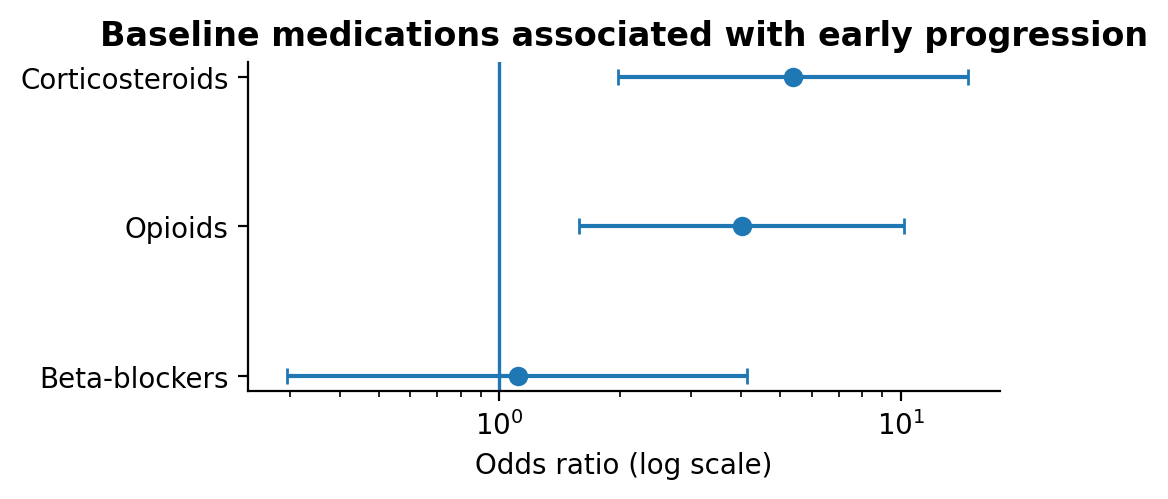

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.contingency_tables import Table2x2
 
xlsx_path = "../../../data/processed/clinical/Subjects_data.xlsx"
df = pd.read_excel(xlsx_path)
df.columns = df.columns.str.strip()
 
def excel_col_to_idx(col):
    col = col.upper().strip()
    idx = 0
    for ch in col:
        idx = idx * 26 + (ord(ch) - ord('A') + 1)
    return idx - 1
 
def coerce_binary(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (bool, np.bool_)):
        return int(x)
    if isinstance(x, (int, float, np.integer, np.floating)) and x in [0, 1]:
        return int(x)
    s = str(x).strip().lower()
    if s in ["1", "true", "yes", "y", "early", "early pd", "early progression"]:
        return 1
    if s in ["0", "false", "no", "n", "non-early", "not early", "non early", "late", "non-early pd"]:
        return 0
    try:
        v = int(float(s))
        return v if v in [0,1] else np.nan
    except:
        return np.nan
 
# Column mapping by Excel letters
early_col = 'Early_PD'
cort_col  = 'Corticoids'
beta_col  = 'Beta_blockers'
opio_col  = 'Opioids'
 
tmp = pd.DataFrame({
    "early": df[early_col].apply(coerce_binary),
    "corticoid": pd.to_numeric(df[cort_col], errors="coerce"),
    "beta_blocker": pd.to_numeric(df[beta_col], errors="coerce"),
    "opioid": pd.to_numeric(df[opio_col], errors="coerce"),
})
 
# Normalize meds to 0/1
for c in ["corticoid", "beta_blocker", "opioid"]:
    tmp[c] = tmp[c].where(tmp[c].isin([0,1]), np.nan).astype("float")
 
# Derived flags
tmp["symptom_meds"] = ((tmp["corticoid"] == 1) | (tmp["opioid"] == 1)).astype("float")
tmp["any_med"] = ((tmp["corticoid"] == 1) | (tmp["beta_blocker"] == 1) | (tmp["opioid"] == 1)).astype("float")
 
def fisher_or_ci(df2, var):
    d = df2[["early", var]].dropna().copy()
    d["early"] = d["early"].astype(int)
    d[var] = d[var].astype(int)
 
    tab = pd.crosstab(d["early"], d[var])
    # ensure 2x2
    for idx in [0,1]:
        if idx not in tab.index:
            tab.loc[idx] = [0,0]
    for col in [0,1]:
        if col not in tab.columns:
            tab[col] = 0
    tab = tab.sort_index().sort_index(axis=1)
 
    # table layout:
    #          var=0  var=1
    # early=0     d      c
    # early=1     b      a
    d00 = int(tab.loc[0,0])
    c01 = int(tab.loc[0,1])
    b10 = int(tab.loc[1,0])
    a11 = int(tab.loc[1,1])
 
    # Fisher exact
    OR_f, p = fisher_exact([[a11, b10], [c01, d00]])
 
    # OR + CI (approx) via statsmodels Table2x2
    t22 = Table2x2(np.array([[a11, b10],[c01, d00]]))
    or_hat = t22.oddsratio
    ci_low, ci_high = t22.oddsratio_confint()
 
    # proportions
    n_early = a11 + b10
    n_nonearly = c01 + d00
    prop_early = a11 / n_early if n_early else np.nan
    prop_nonearly = c01 / n_nonearly if n_nonearly else np.nan
 
    return {
        "var": var,
        "n_early": n_early,
        "n_nonearly": n_nonearly,
        "early_yes": a11,
        "nonearly_yes": c01,
        "early_%": 100*prop_early,
        "nonearly_%": 100*prop_nonearly,
        "OR": or_hat,
        "CI_low": ci_low,
        "CI_high": ci_high,
        "p_fisher": p
    }
 
results = []
for v in ["corticoid", "opioid", "beta_blocker", "symptom_meds", "any_med"]:
    results.append(fisher_or_ci(tmp, v))
 
res_df = pd.DataFrame(results)
res_df["early_%"] = res_df["early_%"].map(lambda x: f"{x:.1f}" if pd.notna(x) else "NA")
res_df["nonearly_%"] = res_df["nonearly_%"].map(lambda x: f"{x:.1f}" if pd.notna(x) else "NA")
res_df["OR"] = res_df["OR"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "NA").astype('float')
res_df["CI"] = [f"{lo:.2f}–{hi:.2f}" for lo,hi in zip(res_df["CI_low"], res_df["CI_high"])]
res_df["p_fisher"] = res_df["p_fisher"].map(lambda x: f"{x:.4g}")
res_df['Medication']=['Corticosteroids','Opioids','Beta-blockers','Symptoms','Any']

print(res_df[["var","n_early","n_nonearly","early_yes","early_%","nonearly_yes","nonearly_%","OR","CI","p_fisher"]].to_string(index=False))
 
#FOREST PLOT FIGURE 2-I
 
import numpy as np
import matplotlib.pyplot as plt
 
# res_plot debe existir (el DataFrame que ya calculaste con OR, CI_low, CI_high)
# res_plot columns: Medication, OR, CI_low, CI_high
res_plot=res_df.iloc[:3,:].copy()
y = np.arange(len(res_plot))[::-1]
or_vals = res_plot["OR"].to_numpy()
ci_lo = res_plot["CI_low"].to_numpy()
ci_hi = res_plot["CI_high"].to_numpy()
 
fig, ax = plt.subplots(figsize=(5.2, 2.6), dpi=200)
 
ax.errorbar(
    or_vals, y,
    xerr=[or_vals - ci_lo, ci_hi - or_vals],
    fmt="o",
    capsize=3,
    elinewidth=1.5,
)
 
ax.axvline(1.0, linewidth=1.2)  # OR=1 reference
ax.set_xscale("log")
 
ax.set_yticks(y)
ax.set_yticklabels(res_plot["Medication"].tolist())
 
ax.set_xlabel("Odds ratio (log scale)")
ax.set_title("Baseline medications associated with early progression", fontweight='bold')
 
# Tight x-limits without extra whitespace
xmin = max(0.1, float(np.min(ci_lo)) * 0.8)
xmax = float(np.max(ci_hi)) * 1.2
ax.set_xlim(xmin, xmax)

import seaborn as sns
sns.despine()
    
plt.tight_layout()
#fig.savefig("ForestPlot_Meds_EarlyPD_clean.svg", bbox_inches="tight")
plt.show()

In [2]:
res_plot

,var,n_early,n_nonearly,early_yes,nonearly_yes,early_%,nonearly_%,OR,CI_low,CI_high,p_fisher,CI,Medication
0,corticoid,22,136,16,45,72.7,33.1,5.39,1.976005,14.716590,0.0006755,1.98–14.72,Corticosteroids
1,opioid,22,136,13,36,59.1,26.5,4.01,1.580921,10.183254,0.004967,1.58–10.18,Opioids
2,beta_blocker,22,136,3,17,13.6,12.5,1.11,0.295421,4.135143,1,0.30–4.14,Beta-blockers
